# Code Assignment Mod6L14 — Confusion Matrix & Metrics on Restaurant Inspections

**Format:** Instructor Guidance → Your Task → We Share (Reflection)

**Goal:** Using the same **classification workflow** and models as last time, build confusion matrices and calculate accuracy, precision, and recall of each model.  


## Instructor Guidance (Pseudocode + Docs)

Use this as a roadmap; students implement below.

**Docs (quick links):**
- Train/Test Split — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html  
- Logistic Regression — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html  
- Confusion Matrix / Classification Report — scikit-learn: https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics  
- `pandas.get_dummies` (one-hot) — https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html

### Guidance (same models as last challenge -- FEEL free to copy and paste the code that you need from the last code assignment)

1) **Load CSV** → preview shape & columns.  
2) **Define target (y)** as a **binary** label: e.g., `CRITICAL FLAG == "Critical"` → 1, else 0 *(positive class = “Critical”)*.  
3) **Pick features (X)**: start small (`SCORE`), then add categorical dummies (`BORO`, `CUISINE DESCRIPTION`), keep it simple.  
4) **Minimal prep**: coerce **only used columns** to numeric (for numeric features); `get_dummies` for categoricals (`drop_first=True`). Drop NA rows on used cols.  
5) **Train–test split (80/20)** with fixed `random_state`.  
6) **Fit the same model** as last time (e.g., `LogisticRegression`), predict on **test**.  
7) **Evaluate**: confusion matrix, **accuracy**, **precision**, **recall**, **F1** (classification_report).  
8) **Repeat for 2 more models** (A (baseline)/B (single term)/C (more than one term)) on the **same split**; compare metrics.  
9) **Decide** which model is better for the business goal based on **precision vs recall** trade-offs.  


## Your Task

Work in pairs. Comment your choices briefly. Keep code simple and readable.

> **Reminder (last challenge model):** You trained **LogisticRegression**, on three models you will use those same 3 models!


### 1) Read the Restaurant Inspection CSV & Preview

In [176]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import mean_squared_error,accuracy_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import seaborn as sns
from sklearn import preprocessing

In [177]:
df = pd.read_csv("../data/DOHMH_New_York_City_Restaurant_Inspection_Results_20251104 copy.csv")

### 2) Define the Binary Target (y)

We’ll predict whether an inspection had a **Critical violation**.

- Target rule: `CRITICAL FLAG == "Critical"` → **1**, else **0**.
- Positive class = **1 (Critical)** — keep this in mind for **precision/recall** meaning.


In [178]:
#turning SCORE column to numeric
df['SCORE'] = pd.to_numeric(df['SCORE'])

# boolean to determine if Critical flag is 'Critical'
df['CRITICAL_NUM'] = (df['CRITICAL FLAG'] == 'Critical').astype(int)

display(df.shape)
display(df.info())

(291278, 28)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291278 entries, 0 to 291277
Data columns (total 28 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CAMIS                  291278 non-null  int64  
 1   DBA                    291274 non-null  object 
 2   BORO                   291278 non-null  object 
 3   BUILDING               290428 non-null  object 
 4   STREET                 291267 non-null  object 
 5   ZIPCODE                288169 non-null  float64
 6   PHONE                  291271 non-null  object 
 7   CUISINE DESCRIPTION    287380 non-null  object 
 8   INSPECTION DATE        291278 non-null  object 
 9   ACTION                 287380 non-null  object 
 10  VIOLATION CODE         285078 non-null  object 
 11  VIOLATION DESCRIPTION  285078 non-null  object 
 12  CRITICAL FLAG          291278 non-null  object 
 13  SCORE                  274939 non-null  float64
 14  GRADE                  142210 non-nu

None

### 3) Create Three Models (you can copy and paste the same modeling code from last code assignment here it is okay if your models have different features as long as you have 3 models)

- **Model A (minimal numeric):** `SCORE` only (lower is better in NYC scoring).  
- **Model B (add location):** `SCORE` + one-hot `BORO`.  
- **Model C (richer categories):** `SCORE` + one-hot `BORO` + top cuisines (one-hot of `CUISINE DESCRIPTION` limited to most frequent K).

> If any column is missing in your file, skip that spec or adjust accordingly.


In [179]:
# MODEL A:
modela = df[['CRITICAL_NUM','SCORE']]

# MODEL B
modelb = df[['CRITICAL_NUM','SCORE','BORO']]

# MODEL C
modelc = df[['CRITICAL_NUM','SCORE','BORO','CUISINE DESCRIPTION']]


In [180]:
modelc['CUISINE DESCRIPTION'].value_counts()

CUISINE DESCRIPTION
American              45314
Chinese               28350
Coffee/Tea            20247
Pizza                 17372
Latin American        13320
                      ...  
Nuts/Confectionary       35
Czech                    15
Polynesian                6
Haute Cuisine             5
Chimichurri               2
Name: count, Length: 90, dtype: int64

### 4) Minimal Cleaning: Drop NAs in Used Columns

Do this **per model** so each spec uses its own “clean” subset (same **target** slice).


In [181]:
# model A cleaning:
# keeping values of modela where score is not na (score has less values than critical_flag)
modela = modela[modela['SCORE'].notna()]
# turning SCORE column into numeric
modela['SCORE'] = pd.to_numeric(modela['SCORE'])


In [182]:
# model B cleaning:
# keeping values of modelb where score is not na (score has less values than critical_flag and boro columns)
modelb = modelb[modelb['SCORE'].notna()]
# turning SCORE column into numeric
modelb['SCORE'] = pd.to_numeric(modelb['SCORE'])
# getting dummy variables of BORO column and merging with modelb
dummies_pd = pd.get_dummies(modelb['BORO'], drop_first=True, prefix='borough',dtype=int)
modelb = pd.concat([modelb, dummies_pd], axis=1)
modelb = modelb.drop('BORO',axis=1)

In [183]:
modelb

,CRITICAL_NUM,SCORE,borough_Brooklyn,borough_Manhattan,borough_Queens,borough_Staten Island
18,1,13.0,1,0,0,0
19,0,0.0,1,0,0,0
36,0,13.0,0,1,0,0
37,0,0.0,0,1,0,0
54,0,0.0,1,0,0,0
...,...,...,...,...,...,...
291273,0,0.0,1,0,0,0
291274,1,40.0,0,1,0,0
291275,1,27.0,1,0,0,0
291276,0,31.0,1,0,0,0


In [ ]:
# model C cleaning:
# keeping values of modelc where score is not na (score has less values than critical_flag and boro columns)
modelc = modelc[modelc['SCORE'].notna()]
# turning SCORE column into numeric
modelc['SCORE'] = pd.to_numeric(modelc['SCORE'])
# getting dummy variables of BORO column (bronx integrated with y-intercept) and merging with modelc
dummies_pd = pd.get_dummies(modelc['BORO'], drop_first=True, prefix='borough')
modelc = pd.concat([modelc, dummies_pd], axis=1)
modelc = modelc.drop('BORO',axis=1)

,CRITICAL_NUM,SCORE,CUISINE DESCRIPTION,borough_Brooklyn,borough_Manhattan,borough_Queens,borough_Staten Island
18,1,13.0,Italian,True,False,False,False
19,0,0.0,African,True,False,False,False
36,0,13.0,Other,False,True,False,False
37,0,0.0,Pizza,False,True,False,False
54,0,0.0,Chinese,True,False,False,False
...,...,...,...,...,...,...,...
291273,0,0.0,Japanese,True,False,False,False
291274,1,40.0,Jewish/Kosher,False,True,False,False
291275,1,27.0,Chinese/Japanese,True,False,False,False
291276,0,31.0,Latin American,True,False,False,False


In [185]:
# CONTINUING MODEL C
# getting dummy values using one hot encoding to only choose most top 5 frequent values
# (merges number 1 with y-intercept and everything within 6 + is put into infrequent)
# We fit the encoder on the 'CUISINE DESCRIPTION' column
ohe = OneHotEncoder(drop='first', sparse_output=False,max_categories=25)
feature_array = ohe.fit_transform(modelc[['CUISINE DESCRIPTION']])
feature_labels = list(ohe.get_feature_names_out())
dummies_skl = pd.DataFrame(feature_array, columns=feature_labels)

#display(dummies_skl)

# Concatenate back to the original dataframe

modelc = pd.concat([modelc.reset_index(drop=True), dummies_skl.reset_index(drop=True)], axis=1)
modelc = modelc.drop('CUISINE DESCRIPTION',axis=1)

In [186]:
modelc.head()
modelc[modelc['CUISINE DESCRIPTION_infrequent_sklearn'] == 1]

# potential for merging some of these food columns into broader categories

,CRITICAL_NUM,SCORE,borough_Brooklyn,borough_Manhattan,borough_Queens,borough_Staten Island,CUISINE DESCRIPTION_Asian/Asian Fusion,CUISINE DESCRIPTION_Bakery Products/Desserts,CUISINE DESCRIPTION_Caribbean,CUISINE DESCRIPTION_Chicken,...,CUISINE DESCRIPTION_Korean,CUISINE DESCRIPTION_Latin American,CUISINE DESCRIPTION_Mediterranean,CUISINE DESCRIPTION_Mexican,CUISINE DESCRIPTION_Pizza,CUISINE DESCRIPTION_Sandwiches,CUISINE DESCRIPTION_Spanish,CUISINE DESCRIPTION_Tex-Mex,CUISINE DESCRIPTION_Thai,CUISINE DESCRIPTION_infrequent_sklearn
1,0,0.0,True,False,False,False,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0,13.0,False,True,False,False,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6,1,9.0,True,False,False,False,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
15,0,31.0,False,False,False,False,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19,0,27.0,False,False,False,False,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274912,1,20.0,False,True,False,False,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
274921,1,12.0,False,True,False,False,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
274927,0,27.0,True,False,False,False,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
274929,1,63.0,False,True,False,False,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### 5) Train–Test Split (same split for all models)

Use **the same random_state** so models A/B/C are comparable.


In [187]:
# TTS FOR ALL MODELS, 70 30 split, stratified on y
np.random.seed(16)
# model A TTS
modelax_train, modelax_test, modelay_train, modelay_test = train_test_split(modela[['SCORE']], modela['CRITICAL_NUM'], test_size=0.3, random_state=16,stratify=modela['CRITICAL_NUM'])

# model B TTS
modelbx_train, modelbx_test, modelby_train, modelby_test = train_test_split(modelb[[col for col in modelb.columns if col != 'CRITICAL_NUM']], modelb['CRITICAL_NUM'], test_size=0.3, random_state=16,stratify=modelb['CRITICAL_NUM'])

# model C TTS
modelcx_train, modelcx_test, modelcy_train, modelcy_test = train_test_split(modelc[[col for col in modelc.columns if col != 'CRITICAL_NUM']], modelc['CRITICAL_NUM'], test_size=0.3, random_state=16,stratify=modelc['CRITICAL_NUM'])


### 6) Fit the Same Models on the Train sets (Logistic Regression), Get Predictions, Print Confusion Matrices & Metric Reports

> **This is new**:  Be sure to look up documentation on `confusion_matrix` and `classification_report`.  Get a matrix and metrics report (accuracy, precision, recall, f1) for each model.


In [188]:
# MODEL A
modelalog_reg = LogisticRegression()
# fitting to model a splits
modelalog_reg.fit(modelax_train, modelay_train)
# predictions for modela
modela_pred = modelalog_reg.predict(modelax_test)


# MODEL B
modelblog_reg = LogisticRegression()
# fitting to model b splits
modelblog_reg.fit(modelbx_train, modelby_train)
# predictions for model b
modelb_pred = modelblog_reg.predict(modelbx_test)


# MODEL C
modelclog_reg = LogisticRegression()
# fitting to model b splits
modelclog_reg.fit(modelcx_train, modelcy_train)
# predictions for model b
modelc_pred = modelclog_reg.predict(modelcx_test)

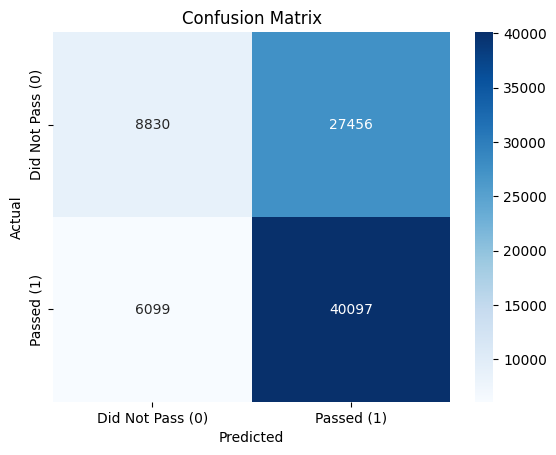


--- Classification Report ---
                  precision    recall  f1-score   support

Did Not Pass (0)       0.59      0.24      0.34     36286
      Passed (1)       0.59      0.87      0.71     46196

        accuracy                           0.59     82482
       macro avg       0.59      0.56      0.52     82482
    weighted avg       0.59      0.59      0.55     82482



In [189]:
from sklearn.metrics import confusion_matrix, classification_report

# Print Confusion Matrices & Metric Reports

cma = confusion_matrix(modelay_test, modela_pred)

# 2. Visualize the confusion matrix
sns.heatmap(cma, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Pass (0)', 'Passed (1)'],
            yticklabels=['Did Not Pass (0)', 'Passed (1)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# 3. Generate the full classification report
print("\n--- Classification Report ---")
print(classification_report(modelay_test, modela_pred, target_names=['Did Not Pass (0)', 'Passed (1)']))


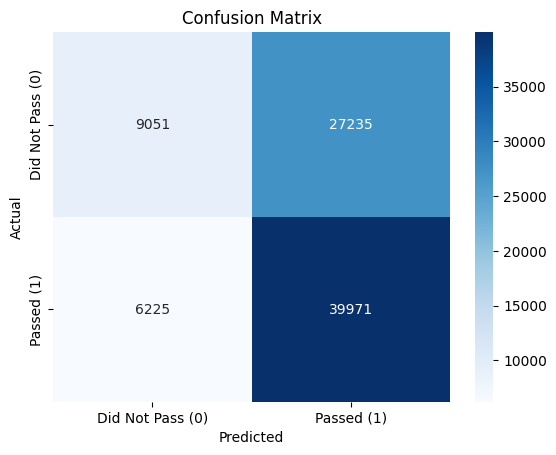


--- Classification Report ---
                  precision    recall  f1-score   support

Did Not Pass (0)       0.59      0.25      0.35     36286
      Passed (1)       0.59      0.87      0.70     46196

        accuracy                           0.59     82482
       macro avg       0.59      0.56      0.53     82482
    weighted avg       0.59      0.59      0.55     82482



In [190]:
# Print Confusion Matrices & Metric Reports

cmb = confusion_matrix(modelby_test, modelb_pred)

# 2. Visualize the confusion matrix
sns.heatmap(cmb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Pass (0)', 'Passed (1)'],
            yticklabels=['Did Not Pass (0)', 'Passed (1)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# 3. Generate the full classification report
print("\n--- Classification Report ---")
print(classification_report(modelby_test, modelb_pred, target_names=['Did Not Pass (0)', 'Passed (1)']))


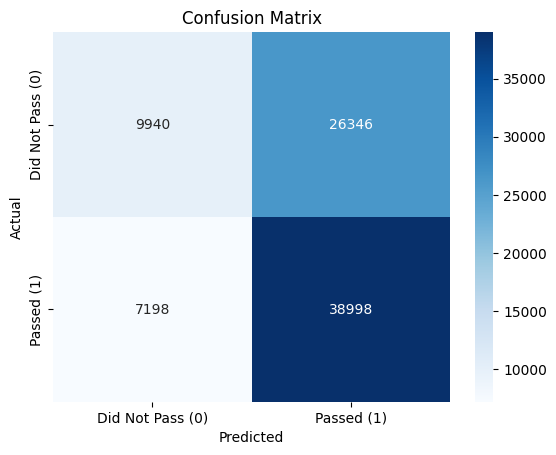


--- Classification Report ---
                  precision    recall  f1-score   support

Did Not Pass (0)       0.58      0.27      0.37     36286
      Passed (1)       0.60      0.84      0.70     46196

        accuracy                           0.59     82482
       macro avg       0.59      0.56      0.54     82482
    weighted avg       0.59      0.59      0.56     82482



In [191]:
# Print Confusion Matrices & Metric Reports

cmc = confusion_matrix(modelcy_test, modelc_pred)

# 2. Visualize the confusion matrix
sns.heatmap(cmc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Pass (0)', 'Passed (1)'],
            yticklabels=['Did Not Pass (0)', 'Passed (1)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# 3. Generate the full classification report
print("\n--- Classification Report ---")
print(classification_report(modelcy_test, modelc_pred, target_names=['Did Not Pass (0)', 'Passed (1)']))


### 7) Visualize One Confusion Matrix 

Be able to interpret this Matrix 

In [ ]:
None



### 8) Decide Which Model Is “Better” — Explain Your Metric Choice

- If the **cost of missing a Critical** violation is high → prioritize **Recall** on the positive class.  
- If the **cost of wrongly flagging Critical** is high → prioritize **Precision** on the positive class.  
- If you want a balance → **F1**.

Write 3–5 sentences justifying your pick using the table above (Precision/Recall/F1).


## We Share (Reflection)

1) **Chosen model (A/B/C)** and **why**, referencing **Precision/Recall/F1** for the **Critical (1)** class.  
2) Your **confusion matrix** and a one-liner in plain English:  
   - “Out of all inspections we predicted **Critical**, **X%** were actually Critical (Precision).  
   - Of all actually **Critical** inspections, we caught **Y%** (Recall).”  